In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import cartopy.io.img_tiles as cimgt

In [77]:
# Load environment variables
load_dotenv()
database_url = os.getenv("DATABASE_URL")

if not database_url:
    raise ValueError("DATABASE_URL not found in .env file")

# Create database engine
engine = create_engine(database_url)

# Read table into DataFrame
df = pd.read_sql("storm_events_details_cleaned", engine)

# Quick sanity check
# pd.set_option('display.max_columns', None)
# print(df.head())
# print(df.shape)
# df.columns.tolist()


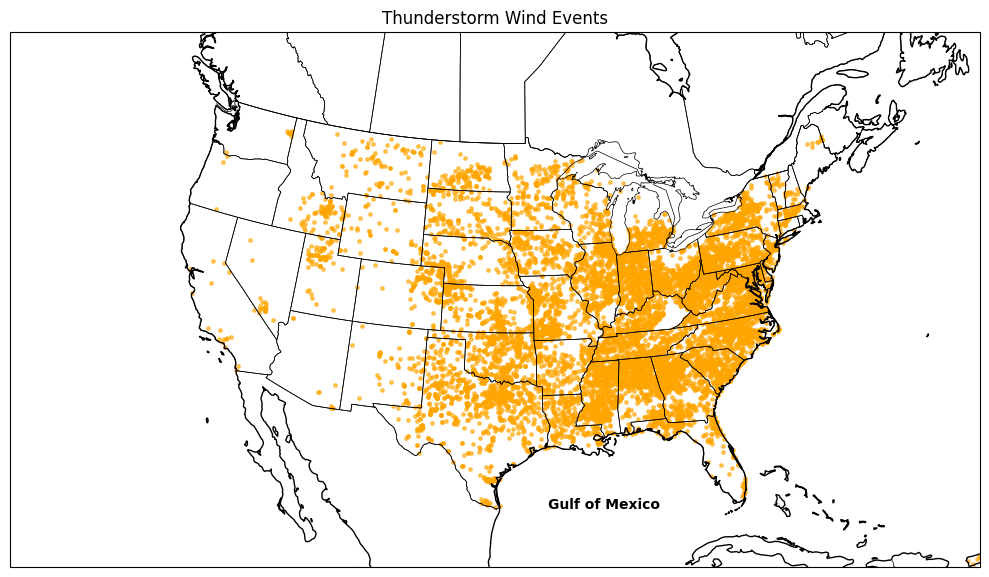

In [78]:
# 1. Filter only Thunderstorm Wind
ts = df[df["EVENT_TYPE"] == "Thunderstorm Wind"].copy()

# 2. Create map
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-130, -65, 22, 52], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Label Gulf of Mexico (optional)
gulf_label_lon = -90
gulf_label_lat = 26
ax.text(
    gulf_label_lon,
    gulf_label_lat,
    "Gulf of Mexico",
    transform=ccrs.PlateCarree(),
    fontsize=10,
    fontweight="bold",
    ha="center",
    va="center",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# 3. Scatter only thunderstorms
ax.scatter(
    ts["BEGIN_LON"],
    ts["BEGIN_LAT"],
    s=6,
    alpha=0.6,
    color="orange",          # or "black"/"red" etc.
    transform=ccrs.PlateCarree()
)

plt.title("Thunderstorm Wind Events")
plt.tight_layout()
plt.show()


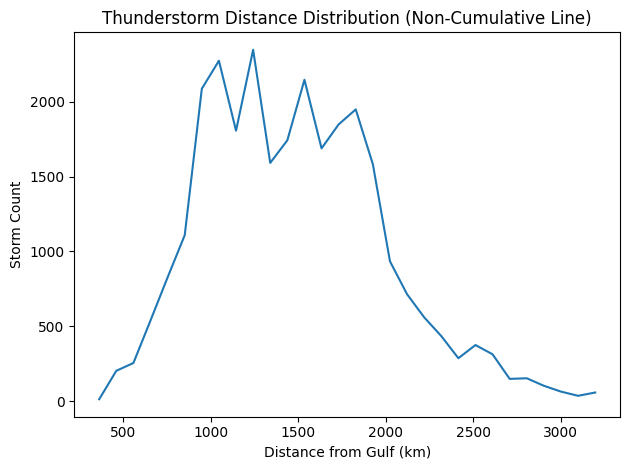

In [79]:

gulf_lat = 26.0
gulf_lon = -90.0

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["dist_to_gulf_km"] = haversine(
    df["BEGIN_LAT"],
    df["BEGIN_LON"],
    gulf_lat,
    gulf_lon
)
cutoff = df["dist_to_gulf_km"].quantile(0.99)
df_clean = df[df["dist_to_gulf_km"] <= cutoff]

dist_sorted = np.sort(df_clean["dist_to_gulf_km"].values)
cum_percent = np.arange(1, len(dist_sorted)+1) / len(dist_sorted) * 100


counts, bin_edges = np.histogram(df_clean["dist_to_gulf_km"], bins=30)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.plot(bin_centers, counts)
plt.xlabel("Distance from Gulf (km)")
plt.ylabel("Storm Count")
plt.title("Thunderstorm Distance Distribution (Non-Cumulative Line)")
plt.tight_layout()
plt.show()



In [ ]:
# import requests
# from tqdm import tqdm

# def batch_elevation(df, lat_col, lon_col, batch_size=100):
#     results = []

#     for i in tqdm(range(0, len(df), batch_size), desc="Batch Altitude"):
#         chunk = df.iloc[i:i+batch_size]
#         locations = "|".join(
#             f"{lat},{lon}" for lat, lon in zip(chunk[lat_col], chunk[lon_col])
#         )

#         try:
#             url = "https://api.open-elevation.com/api/v1/lookup"
#             r = requests.get(url, params={"locations": locations}, timeout=10)
#             data = r.json()["results"]
#             results.extend([pt["elevation"] for pt in data])
#         except:
#             results.extend([0] * len(chunk))

#     return results

# df["ALTITUDE_M"] = batch_elevation(df, "BEGIN_LAT", "BEGIN_LON")

# df.to_csv()


Batch Altitude: 100%|██████████| 285/285 [12:05<00:00,  2.55s/it]


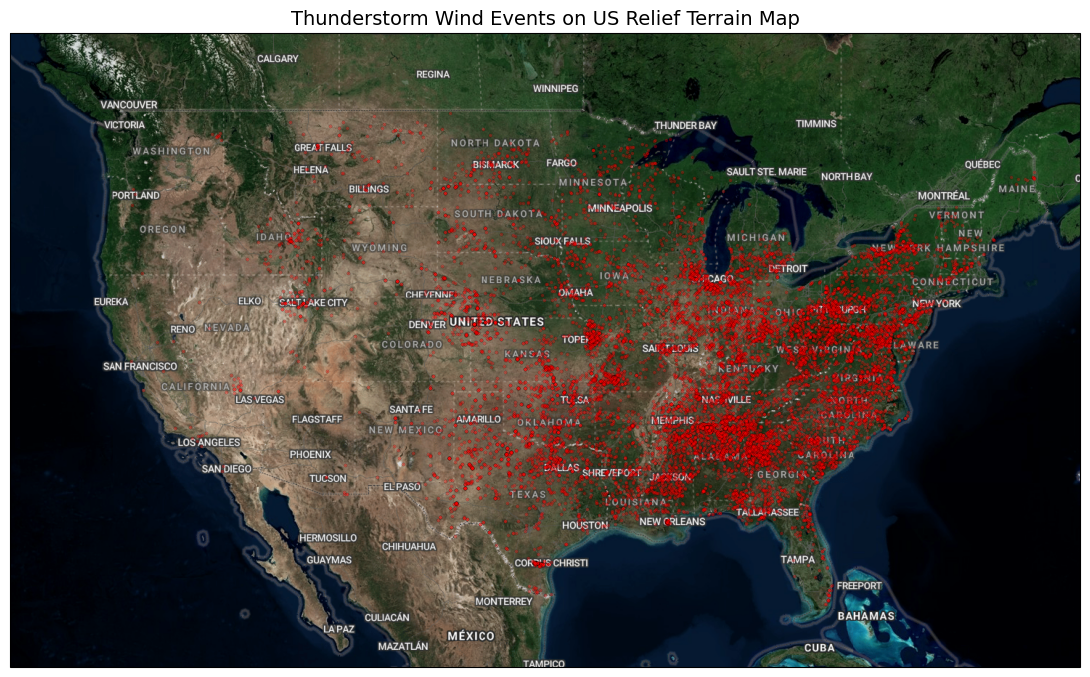

In [81]:
# 1. Filter only Thunderstorm Wind events
ts = df[df["EVENT_TYPE"] == "Thunderstorm Wind"].copy()

# 2. Stadia terrain tiles (relief-style)
STADIA_API_KEY = "8576fba4-5141-4c6b-be54-4ba3881668ea"  # (rotate later!)
terrain = cimgt.StadiaMapsTiles(
    apikey=STADIA_API_KEY,
    style="alidade_satellite"        # relief-style physical map
)

# 42 Figure + map
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=terrain.crs)

# Continental US extent
ax.set_extent([-130, -65, 22, 52], crs=ccrs.PlateCarree())

# Higher zoom level → more detailed terrain (try 6–8)
ax.add_image(terrain, 5)

# 4. Plot storm points (light, so terrain is visible)
ax.scatter(
    ts["BEGIN_LON"],
    ts["BEGIN_LAT"],
    s=6,
    color="red",          # light points
    alpha=0.3,              # a bit transparent
    edgecolors="black",     # thin outline for visibility
    linewidths=0.2,
    transform=ccrs.PlateCarree()
)

plt.title("Thunderstorm Wind Events on US Relief Terrain Map", fontsize=14)
plt.tight_layout()
plt.savefig("./infographics/Satelite_Map_Plot", dpi=300)
plt.show()


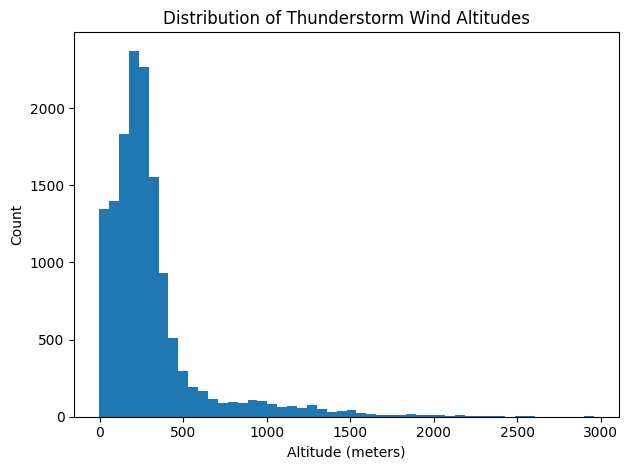

In [80]:
df_alt = pd.read_csv("data/storm_data_cleaned_with_altitude.csv")

# ✅ Filter only Thunderstorm Wind
ts = df_alt[df_alt["EVENT_TYPE"] == "Thunderstorm Wind"]

plt.figure()
plt.hist(ts["ALTITUDE_M"], bins=50)
plt.title("Distribution of Thunderstorm Wind Altitudes")
plt.xlabel("Altitude (meters)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
